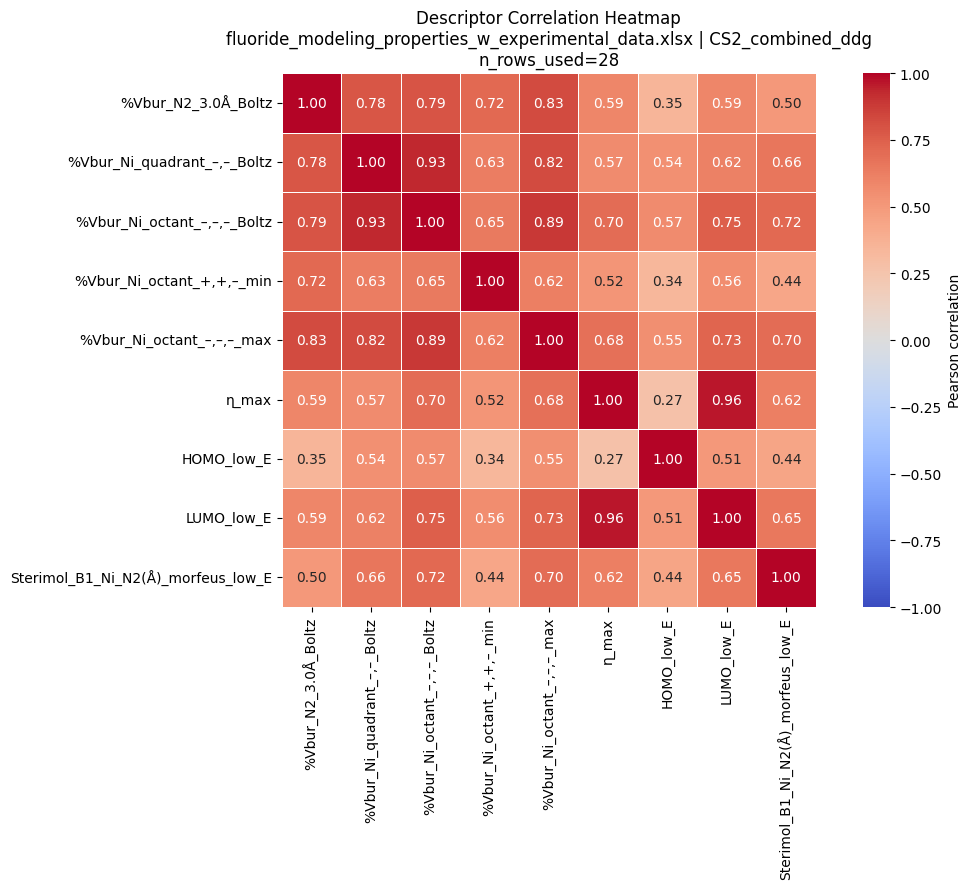

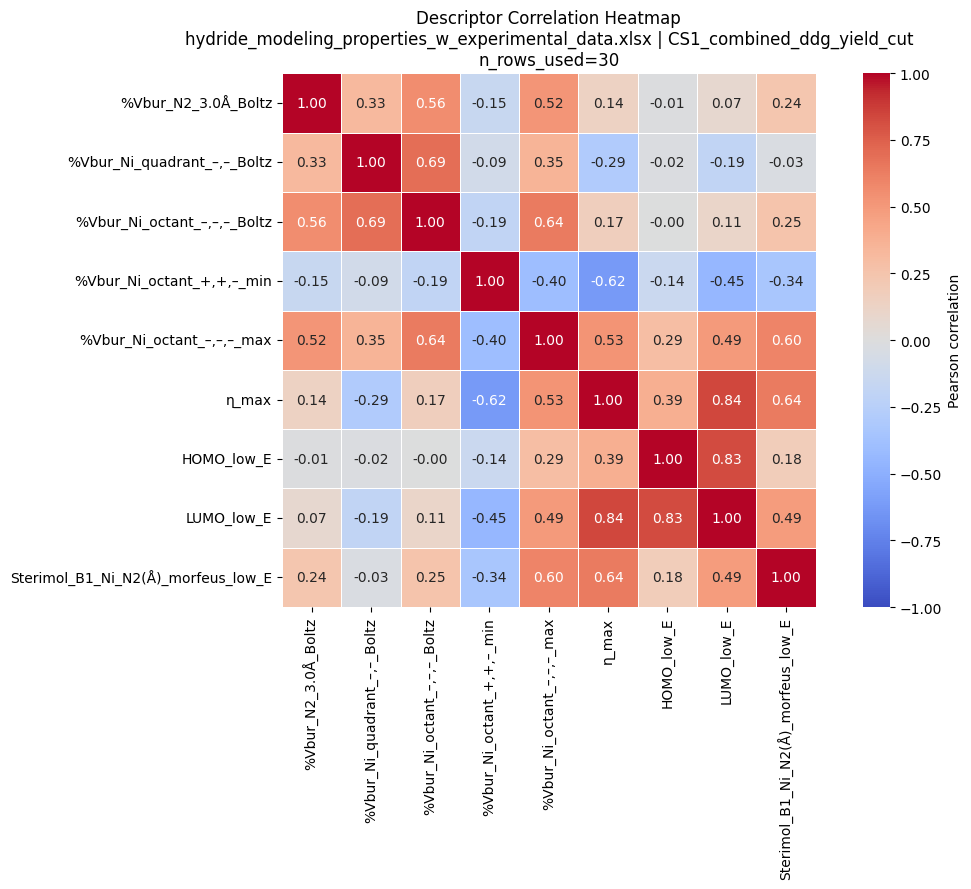

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def _default_sheet_for_file(excel_file):
    file_name = Path(excel_file).name.lower()
    if "fluoride" in file_name:
        return "CS2_combined_ddg"
    if "hydride" in file_name:
        return "CS1_combined_ddg_yield_cut"
    raise ValueError(
        "Could not infer sheet name from file name. "
        "Use a file containing 'fluoride' or 'hydride', or pass sheet_name explicitly."
    )


def _promote_first_row_to_header(df):
    promoted_df = df.copy()
    promoted_df.columns = promoted_df.iloc[0].tolist()
    promoted_df = promoted_df.iloc[1:].reset_index(drop=True)
    return promoted_df


def _load_descriptor_sheet(excel_file, sheet_name, descriptors):
    df = pd.read_excel(excel_file, sheet_name=sheet_name, dtype=object)

    if all(descriptor in df.columns for descriptor in descriptors):
        return df

    promoted_df = _promote_first_row_to_header(df)
    if all(descriptor in promoted_df.columns for descriptor in descriptors):
        return promoted_df

    return promoted_df


def plot_descriptor_pairwise_correlation_heatmap(
    descriptors,
    excel_file,
    sheet_name=None,
    drop_duplicate_descriptor_rows=True,
    cmap="coolwarm",
    annot=True,
    figsize=(12, 9),
):
    """
    Plot pairwise descriptor correlation heatmap for fluoride/hydride combined sheets.

    Parameters
    ----------
    descriptors : list[str]
        Descriptor column names to correlate.
    excel_file : str or Path
        Input Excel file path. For supported files, default sheet is inferred as:
        - fluoride -> CS2_combined_ddg
        - hydride -> CS1_combined_ddg_yield_cut
    sheet_name : str, optional
        Override default sheet selection.
    drop_duplicate_descriptor_rows : bool, default=True
        Remove duplicated rows across the descriptor columns before correlation.
    """
    if not descriptors:
        raise ValueError("descriptors must be a non-empty list.")

    excel_file = Path(excel_file)
    if not excel_file.exists():
        raise FileNotFoundError(f"File not found: {excel_file}")

    selected_sheet = sheet_name or _default_sheet_for_file(excel_file)
    df = _load_descriptor_sheet(excel_file, selected_sheet, descriptors)

    missing = [descriptor for descriptor in descriptors if descriptor not in df.columns]
    if missing:
        raise KeyError(
            f"Missing descriptors in sheet '{selected_sheet}': {missing}"
        )

    descriptor_df = df[descriptors].apply(pd.to_numeric, errors="coerce")
    descriptor_df = descriptor_df.dropna(axis=0, how="any")

    if drop_duplicate_descriptor_rows:
        descriptor_df = descriptor_df.drop_duplicates()

    if descriptor_df.shape[0] < 2:
        raise ValueError(
            "Not enough valid rows after cleaning to compute correlation (need at least 2)."
        )

    corr_df = descriptor_df.corr()

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr_df,
        ax=ax,
        cmap=cmap,
        annot=annot,
        fmt=".2f",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Pearson correlation"},
    )
    ax.set_title(
        f"Descriptor Correlation Heatmap\n{excel_file.name} | {selected_sheet}\n"
        f"n_rows_used={len(descriptor_df)}"
    )
    plt.tight_layout()
    plt.show()

    return corr_df


descriptors = ['%Vbur_N2_3.0Å_Boltz', '%Vbur_Ni_quadrant_–,–_Boltz', '%Vbur_Ni_octant_–,–,–_Boltz', '%Vbur_Ni_octant_+,+,–_min', '%Vbur_Ni_octant_–,–,–_max', 'η_max', 'HOMO_low_E', 'LUMO_low_E', 'Sterimol_B1_Ni_N2(Å)_morfeus_low_E']#['HOMO_low_E', 'Sterimol_B1_N2_C2(Å)_morfeus_low_E', 'Sterimol_B5_C2_N2(Å)_morfeus_min', '%Vbur_Ni_octant_–,–,–_Boltz']

corr_f = plot_descriptor_pairwise_correlation_heatmap(
    descriptors,
    "/Users/julesschleinitz/Desktop/Code/BNNY/fluoride_modeling_properties_w_experimental_data.xlsx",
)

corr_h = plot_descriptor_pairwise_correlation_heatmap(
    descriptors,
    "/Users/julesschleinitz/Desktop/Code/BNNY/hydride_modeling_properties_w_experimental_data.xlsx",
)

In [28]:
df = pd.read_excel(
    '../hydride_modeling_properties_w_experimental_data.xlsx',
    sheet_name='CS1_combined_ddg_yield_cut',
    header=1,
)
df = df[['ligand_class', 'NMR_shift_C2_min']]
df


,ligand_class,NMR_shift_C2_min
0,biim,9.1317
1,pyox,-4.2530
2,pyox,-4.2530
3,pyox,-3.1178
4,biox,4.8766
5,biox,4.8766
6,biox,5.6180
7,biox,5.6180
8,biox,5.2366
9,biox,5.2366


/var/folders/_g/6jml0x190szd85mnhhx81ydm0000gn/T/ipykernel_87079/532422474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


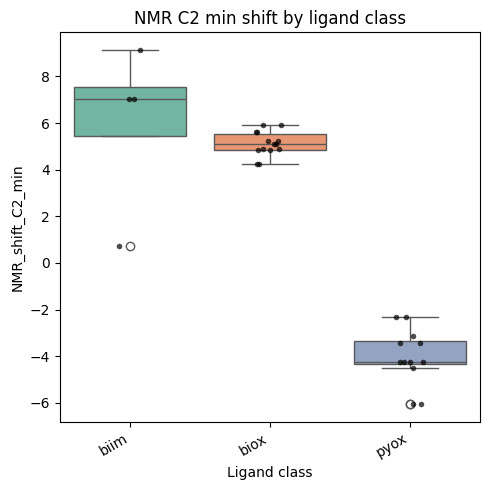

In [32]:
df_plot = df.dropna(subset=['NMR_shift_C2_min']).copy()
df_plot['NMR_shift_C2_min'] = pd.to_numeric(df_plot['NMR_shift_C2_min'], errors='coerce')
df_plot = df_plot.dropna(subset=['NMR_shift_C2_min'])

order = sorted(df_plot['ligand_class'].dropna().unique())

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(
    data=df_plot,
    x='ligand_class',
    y='NMR_shift_C2_min',
    order=order,
    #inner=None,
    palette='Set2',
    #alpha=0.6,
    ax=ax,
)
sns.stripplot(
    data=df_plot,
    x='ligand_class',
    y='NMR_shift_C2_min',
    order=order,
    color='black',
    size=4,
    jitter=True,
    alpha=0.7,
    ax=ax,
)
ax.set_xlabel('Ligand class')
ax.set_ylabel('NMR_shift_C2_min')
ax.set_title('NMR C2 min shift by ligand class')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
